In [10]:
import gensim
from gensim.models import Word2Vec
from gensim.models import FastText
from sklearn.decomposition import PCA
from matplotlib import pyplot as plt
import numpy as np

In [11]:
from pathlib import Path

corpus_path = Path("../data/processed/corpus_raw.txt")
sentences = []

with open(corpus_path, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            sentences.append(line.split())


print("Số lượng câu:", len(sentences))
print("\nCâu đầu tiên chuẩn Word Embedding:")
print(sentences[0][:10])

Số lượng câu: 69

Câu đầu tiên chuẩn Word Embedding:
['công', 'báo', '983', '984', '2582024', '3', 'quốc_hội', 'cộng_hòa', 'xã_hội_chủ_nghĩa_việt_nam', 'độc_lập']


In [12]:
corpus_path_2 = Path("../data/processed/corpus_raw_2.txt")
sentences_2 = []

with open(corpus_path_2, "r", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if line:
            sentences_2.append(line.split())


print("Số lượng câu:", len(sentences_2))
print("\nCâu đầu tiên chuẩn Word Embedding:")
print(sentences_2[0][:10])

Số lượng câu: 88

Câu đầu tiên chuẩn Word Embedding:
['phủ', 'cộng_hòa', 'xã_hội_chủ_nghĩa_việt_nam', 'độc_lập', 'tự', 'hạnh_phúc', '168', '2024', 'nđcp', 'hà_nội']


3. Skip gram

In [13]:
skipgram = Word2Vec(sentences, vector_size=100, window=5, min_count=1, workers=4, sg=1)

skipgram_2 = Word2Vec(sentences_2, vector_size=100, window=5, min_count=1, workers=4, sg=1)

In [14]:
print(skipgram)

print(skipgram_2)

Word2Vec<vocab=1484, vector_size=100, alpha=0.025>
Word2Vec<vocab=1576, vector_size=100, alpha=0.025>


In [15]:
skipgram.wv['cộng_hòa']

array([-1.66805834e-02,  6.09231405e-02, -3.36614065e-02,  6.78045899e-02,
        7.84645453e-02, -9.51176956e-02,  4.22951728e-02,  3.64670128e-01,
        1.77823063e-02, -4.63926941e-02, -1.03452168e-01, -2.60467052e-01,
       -1.45794135e-02,  9.22822133e-02, -3.37407850e-02, -9.12629515e-02,
        1.49231464e-01, -1.66754425e-01, -1.37010578e-03, -3.43997300e-01,
        2.15652976e-02,  2.39320118e-02, -1.96856670e-02, -9.64567289e-02,
        2.57209619e-03, -1.72652062e-02, -1.76544741e-01, -4.85671610e-02,
       -1.45172507e-01,  4.98575084e-02,  1.58618763e-01,  1.16971634e-01,
        7.58024901e-02, -8.67219940e-02, -2.03487083e-01,  1.93767652e-01,
        3.17463949e-02, -1.78381145e-01,  9.43205436e-04, -2.62879163e-01,
       -5.21367528e-02,  1.02298511e-02,  1.14351831e-01, -2.02454403e-02,
        1.38209462e-01,  6.36764336e-03, -1.44723967e-01, -4.25422331e-05,
        1.50868520e-01,  1.17449693e-01,  2.37459373e-02, -4.46434692e-02,
        3.10397595e-02,  

In [16]:
skipgram_2.wv['cộng_hòa']

array([-0.06287698, -0.02559773,  0.0240838 , -0.04512723, -0.01863031,
       -0.04194076,  0.0039478 ,  0.09326794, -0.05933573, -0.07565872,
       -0.12256931, -0.06639214, -0.06113274,  0.00063561,  0.047429  ,
        0.0186271 ,  0.00593187, -0.0612965 , -0.03086958, -0.10522094,
        0.03326241,  0.11089332, -0.02133297, -0.10342991,  0.00781406,
        0.012353  , -0.07045718, -0.10033907, -0.02660078,  0.08348306,
        0.12937507,  0.00222787, -0.01647869, -0.02504493, -0.01452035,
        0.16160439, -0.0176172 ,  0.01005566, -0.06716768, -0.1733874 ,
       -0.06597784, -0.14005893, -0.0982269 ,  0.01441931,  0.0341881 ,
       -0.01536726, -0.03527083,  0.04907073,  0.010418  , -0.02077757,
        0.06028927, -0.07246645, -0.01802719,  0.03604056, -0.02823416,
        0.08456925, -0.00438559,  0.0435162 , -0.1248477 ,  0.02020149,
       -0.05066751,  0.01341348,  0.02798258,  0.06978188, -0.14199334,
        0.12905827, -0.03701825,  0.06525949, -0.01011263,  0.19

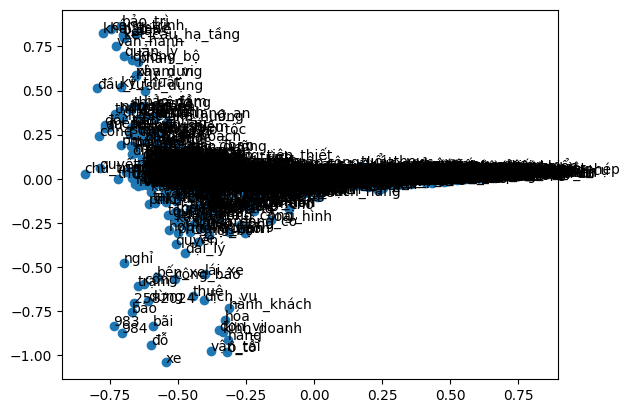

In [17]:
# save model
skipgram.save('skipgram.bin')
# load model
skipgram = Word2Vec.load('skipgram.bin')
# T -SNE plot í one of the way to evaluate word embedding
X = skipgram.wv[skipgram.wv.index_to_key]
pca = PCA(n_components=2)
result = pca.fit_transform(X)
plt.scatter(result[:,0], result[:,1])
words = list(skipgram.wv.index_to_key)
for i, word in enumerate(words):
  plt.annotate(word, xy=(result[i, 0], result[i, 1]))
plt.show()

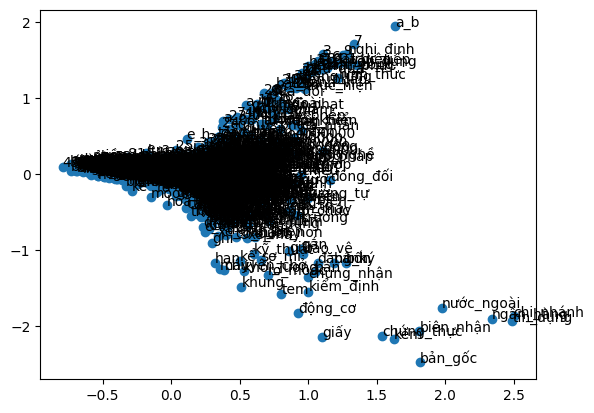

In [18]:
# save model
skipgram_2.save('skipgram_2.bin')
# load model
skipgram_2 = Word2Vec.load('skipgram_2.bin')
# T -SNE plot í one of the way to evaluate word embedding
X = skipgram_2.wv[skipgram_2.wv.index_to_key]
pca = PCA(n_components=2)
result = pca.fit_transform(X)
plt.scatter(result[:,0], result[:,1])
words = list(skipgram_2.wv.index_to_key)
for i, word in enumerate(words):
  plt.annotate(word, xy=(result[i, 0], result[i, 1]))
plt.show()

4. Continuous Bag of Words (CBOW)

In [19]:
cbow = Word2Vec(sentences,vector_size=50, window= 3, min_count=1, sg= 0)
print(cbow)

cbow_2 = Word2Vec(sentences_2,vector_size=50, window= 3, min_count=1, sg= 0)
print(cbow_2)

Word2Vec<vocab=1484, vector_size=50, alpha=0.025>
Word2Vec<vocab=1576, vector_size=50, alpha=0.025>


In [20]:
cbow.wv['cộng_hòa']

array([ 0.0309191 , -0.05419985, -0.03621984, -0.01847242, -0.00602049,
       -0.06114218,  0.12159538,  0.10764843, -0.06862509, -0.040558  ,
       -0.00211599, -0.09213775,  0.02903475,  0.03183237, -0.04028559,
        0.05822643,  0.09619474, -0.00677404, -0.14632158, -0.04008322,
        0.04406932,  0.06964916,  0.10709259, -0.0882003 ,  0.0660335 ,
       -0.00760261, -0.05171277,  0.02575093, -0.09807982, -0.00358714,
        0.01059001,  0.00081579, -0.02736598, -0.04297238,  0.00060293,
        0.04869999,  0.09533904,  0.02028046,  0.03849916, -0.07328011,
        0.13444164, -0.01912359, -0.01680412,  0.00530174,  0.13843039,
        0.03414516, -0.00413671, -0.03971229,  0.09462691,  0.05482637],
      dtype=float32)

In [21]:
cbow_2.wv['cộng_hòa']

array([ 0.01246808, -0.02272196, -0.00994641,  0.06096585, -0.01330515,
       -0.0465459 ,  0.04155936,  0.07098983, -0.06746541, -0.00966019,
        0.01329525, -0.05433739,  0.03258234,  0.0325202 , -0.04184478,
        0.04285021,  0.02797104, -0.01304516, -0.07543041, -0.05117778,
       -0.0097563 ,  0.07330052,  0.04367655, -0.06816959,  0.01521127,
        0.01029111, -0.03810958,  0.00803802, -0.05978557,  0.0468012 ,
        0.00735462, -0.00444202, -0.00666133,  0.0283809 , -0.08116215,
        0.05616638,  0.04575905,  0.00287751, -0.02404818, -0.05837591,
        0.06388644, -0.03026982, -0.01930797, -0.00630666,  0.12593088,
       -0.00370453, -0.04511554, -0.04173402,  0.01127512,  0.0059476 ],
      dtype=float32)

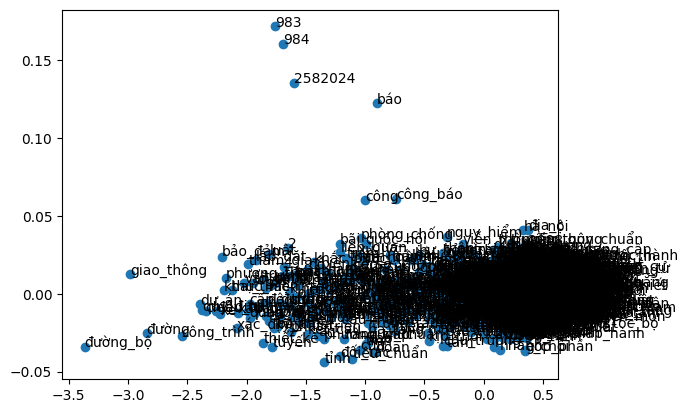

In [22]:
# save model
cbow.save('cbow.bin')
# load model
cbow = Word2Vec.load('cbow.bin')
# T-SNE plot - to evaluate word embedding
X = cbow.wv[cbow.wv.index_to_key]
pca = PCA(n_components=2)
result = pca.fit_transform(X)
plt.scatter(result[:,0], result[:,1])
words = list(cbow.wv.index_to_key)
for i, word in enumerate(words):
  plt.annotate(word, xy=(result[i, 0], result[i, 1]))
plt.show()

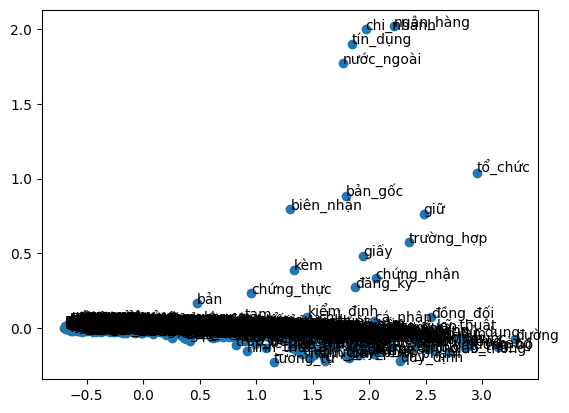

In [23]:
# save model
cbow_2.save('cbow_2.bin')
# load model
cbow_2 = Word2Vec.load('cbow_2.bin')
# T-SNE plot - to evaluate word embedding
X = cbow_2.wv[cbow_2.wv.index_to_key]
pca = PCA(n_components=2)
result = pca.fit_transform(X)
plt.scatter(result[:,0], result[:,1])
words = list(cbow_2.wv.index_to_key)
for i, word in enumerate(words):
  plt.annotate(word, xy=(result[i, 0], result[i, 1]))
plt.show()

5. Implementing fastText

In [24]:
fast = FastText(sentences, window=1, min_count=1, workers=5, min_n=1, max_n=2)

fast_2 = FastText(sentences_2, window=1, min_count=1, workers=5, min_n=1, max_n=2)

In [25]:
print(fast.wv['cộng_hòa'])

[-0.8990363   0.32911348 -0.7669148   0.49241722 -0.19903006  0.17335133
  0.04947697 -0.27920148 -0.3660391  -0.26898476  0.42380846  0.2331045
 -0.6777265  -0.49200615  0.11255565  0.5049067  -0.11589122 -0.7738093
 -0.49311256 -0.5567731   0.95553166 -0.05589725 -0.10526735  0.18566853
  0.2612713   0.0303      0.01639964 -0.11899719  0.32694393  0.4588925
  0.1108927  -0.45109722  0.34417766 -0.11143053  0.3063732   0.26982275
  0.51160586 -0.592333   -0.45483002 -0.20577538  0.5815116   0.06095586
 -0.14573649  0.19778247  0.00514232  0.15224728 -0.4529451  -0.8470813
  0.16723128 -0.10649283  0.47141573  0.5039276  -0.24076465  0.1629493
  0.05801577  0.11407033  0.36456695  0.24370377 -0.19335131  0.00649802
 -0.10475233  0.30128786 -0.12635143  0.37120333  0.34687078 -0.6156328
  0.27834332 -0.37024176  0.03966366 -0.2082457  -0.15335016 -0.32720038
  0.5348028  -0.46607447 -0.3235919  -0.33917934 -0.08833201  0.39233053
  0.09999157  0.5911292  -0.34048235 -0.06844751  0.33756

In [26]:
print(fast_2.wv['cộng_hòa'])

[-0.9046282   0.30253378 -0.42241266  0.4272069  -0.43436217  0.64242077
  0.1647507  -0.5253341  -0.2423456  -0.52669615  0.6211765  -0.24478656
 -0.9501276  -0.9429708  -0.09454915  0.10778194  0.3561052  -0.8688116
 -0.284549   -0.07468923  1.2800537  -0.15881902  0.32616603  0.13815184
  0.3855592  -0.5171472  -0.25243947 -0.27679145  0.49196804  0.4936008
  0.00262769 -0.6823876   0.07746018 -0.5723436   0.09173687  0.58218086
  0.19445902 -0.9424994  -0.39216948 -0.1596229   0.61874175 -0.02833842
 -0.03545957  0.19481198  0.23877324 -0.42263594 -0.01278448 -0.33929065
 -0.00204259 -0.08078644  0.6938965   0.06830634  0.00267366  0.14504392
  0.5391202   0.11901322  0.06594469  0.01787685 -0.40178078 -0.19831358
 -0.15110223  0.44547972 -0.02101359  0.31861618 -0.10512471 -0.09185506
  0.2954051  -0.5043364   0.12655541 -0.23208311  0.20137109 -0.32304204
  0.26021862 -0.6729422  -0.5021407  -0.18888813 -0.45401397  0.32406312
  0.07701255  0.41366637 -0.36035812  0.09708187  0.0

In [27]:
# save model
fast.save('fast.bin')
fast_2.save('fast_2.bin')
# load model
fast = FastText.load('fast.bin')
fast_2 = FastText.load('fast_2.bin')

Đang tính toán T-SNE...


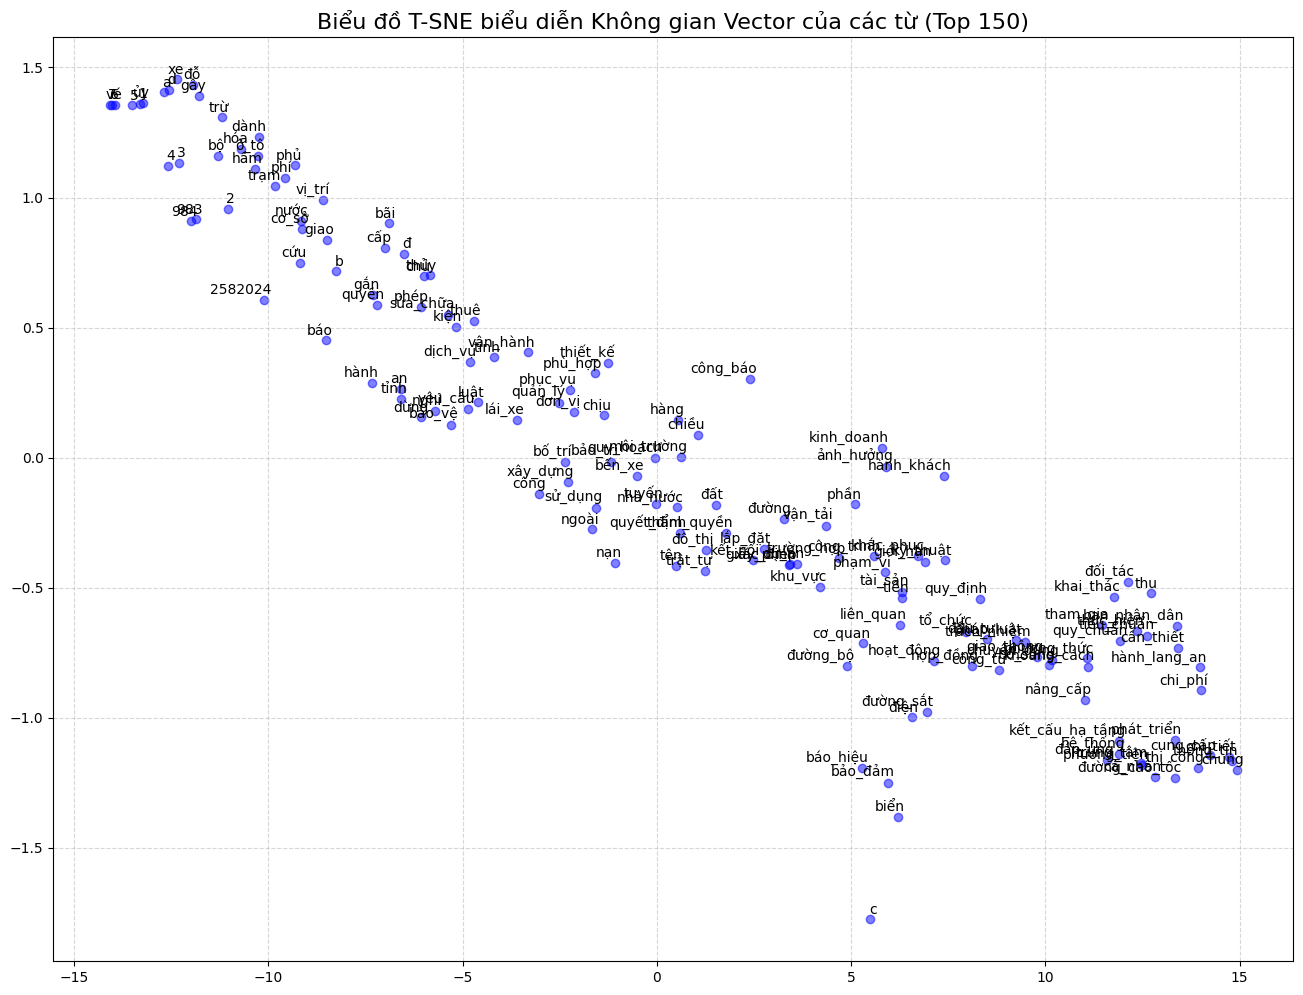

In [28]:
from sklearn.manifold import TSNE

# 1. Trích xuất dữ liệu (Chỉ lấy Top 150 từ đầu tiên để biểu đồ không bị rối)
so_luong_tu = 150
words = list(fast.wv.index_to_key)[:so_luong_tu]
X = fast.wv[words] # Lấy ma trận vector của 150 từ này

# 2. Chạy thuật toán T-SNE để ép từ 300 chiều xuống còn 2 chiều (x, y)
print("Đang tính toán T-SNE...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
result = tsne.fit_transform(X)

# 3. Vẽ biểu đồ
plt.figure(figsize=(16, 12)) # Cài đặt kích thước khung hình to ra
plt.scatter(result[:, 0], result[:, 1], color='blue', alpha=0.5)

# 4. Gắn nhãn (chữ) cho từng điểm ảnh
for i, word in enumerate(words):
    plt.annotate(
        word, 
        xy=(result[i, 0], result[i, 1]),
        xytext=(5, 2), 
        textcoords='offset points',
        ha='right', 
        va='bottom',
        fontsize=10
    )

plt.title("Biểu đồ T-SNE biểu diễn Không gian Vector của các từ (Top 150)", fontsize=16)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Đang tính toán T-SNE...


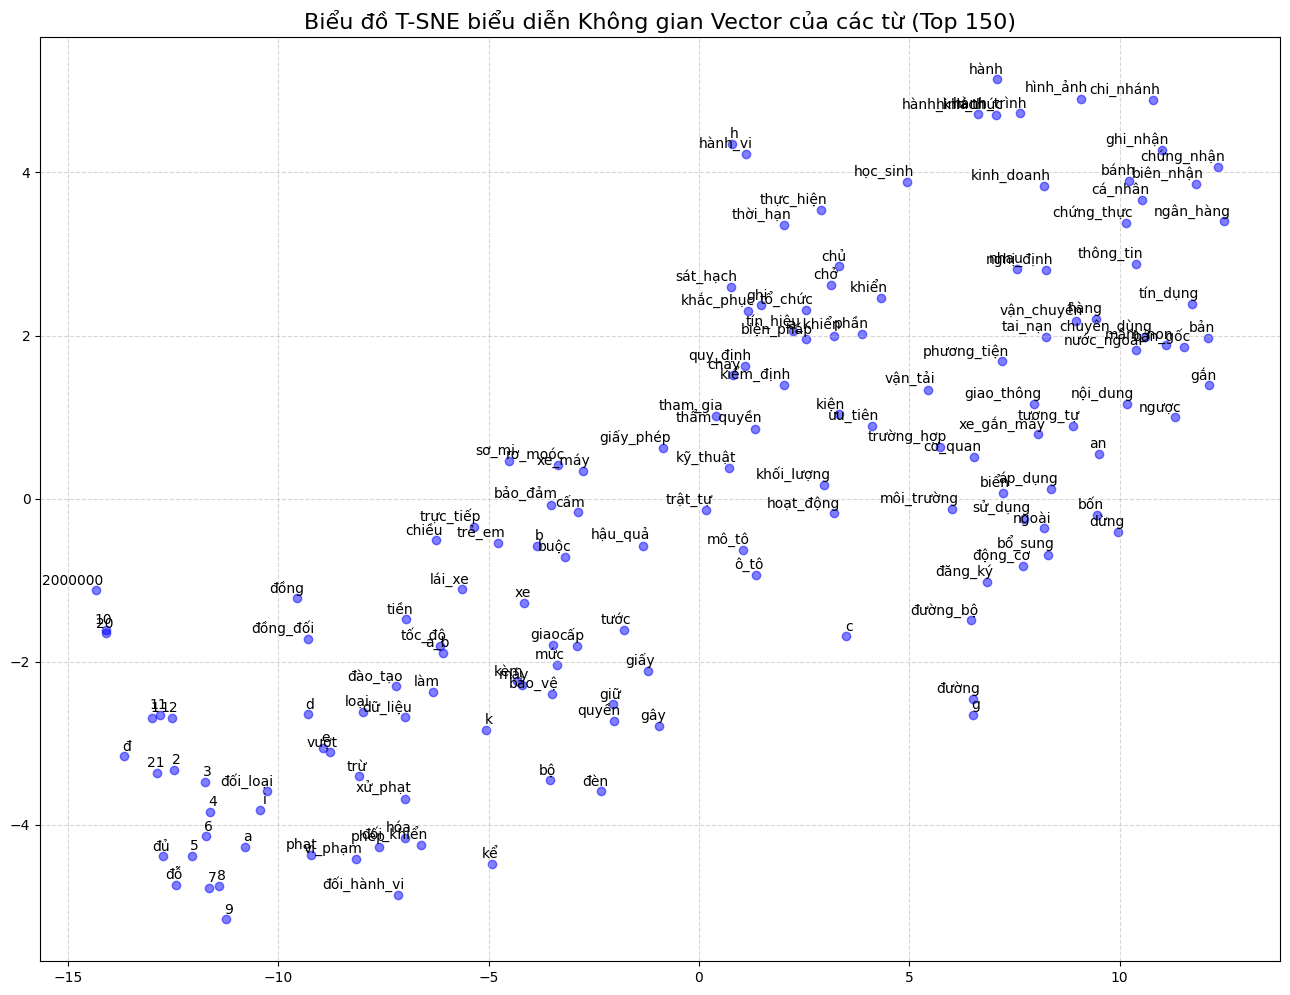

In [29]:
# 1. Trích xuất dữ liệu (Chỉ lấy Top 150 từ đầu tiên để biểu đồ không bị rối)
so_luong_tu = 150
words_2 = list(fast_2.wv.index_to_key)[:so_luong_tu]
X_2 = fast_2.wv[words_2] # Lấy ma trận vector của 150 từ này

# 2. Chạy thuật toán T-SNE để ép từ 300 chiều xuống còn 2 chiều (x, y)
print("Đang tính toán T-SNE...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
result_2 = tsne.fit_transform(X_2)

# 3. Vẽ biểu đồ
plt.figure(figsize=(16, 12)) # Cài đặt kích thước khung hình to ra
plt.scatter(result_2[:, 0], result_2[:, 1], color='blue', alpha=0.5)

# 4. Gắn nhãn (chữ) cho từng điểm ảnh
for i, word in enumerate(words_2):
    plt.annotate(
        word, 
        xy=(result_2[i, 0], result_2[i, 1]),
        xytext=(5, 2), 
        textcoords='offset points',
        ha='right', 
        va='bottom',
        fontsize=10
    )

plt.title("Biểu đồ T-SNE biểu diễn Không gian Vector của các từ (Top 150)", fontsize=16)
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

PhoBERT

In [30]:
!pip install transformers torch

from transformers import AutoModel, AutoTokenizer
import torch

# Tải mô hình PhoBERT
phobert = AutoModel.from_pretrained("vinai/phobert-base")
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")

# Câu ví dụ
sentence = "Người điều khiển xe mô tô hai bánh không đội mũ bảo hiểm sẽ bị xử phạt."

# 1. Tokenize câu
input_ids = tokenizer.encode(sentence, return_tensors='pt')

# 2. Lấy embedding
# Chúng ta sẽ lấy vector của token [CLS] (token đầu tiên) để đại diện cho cả câu
with torch.no_grad():
    features = phobert(input_ids)
    sentence_embedding = features[0][:, 0, :].numpy()

print("Kích thước của vector nhúng:", sentence_embedding.shape)
print("\nMột phần của vector nhúng:")
print(sentence_embedding[0, :50])


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Defaulting to user installation because normal site-packages is not writeable
  Using cached transformers-5.3.0-py3-none-any.whl.metadata (32 kB)
  Using cached huggingface_hub-1.7.2-py3-none-any.whl.metadata (13 kB)
  Using cached regex-2026.2.28-cp312-cp312-win_amd64.whl.metadata (41 kB)
  Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl.metadata (7.4 kB)
  Using cached safetensors-0.7.0-cp38-abi3-win_amd64.whl.metadata (4.2 kB)
  Using cached hf_xet-1.4.2-cp37-abi3-win_amd64.whl.metadata (4.9 kB)
Using cached transformers-5.3.0-py3-none-any.whl (10.7 MB)
Using cached huggingface_hub-1.7.2-py3-none-any.whl (618 kB)
Using cached regex-2026.2.28-cp312-cp312-win_amd64.whl (277 kB)
Using cached safetensors-0.7.0-cp38-abi3-win_amd64.whl (341 kB)
Using cached tokenizers-0.22.2-cp39-abi3-win_amd64.whl (2.7 MB)
Using cached hf_xet-1.4.2-cp37-abi3-win_amd64.whl (3.7 MB)
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface-hub 0.33.2
    Uninstalling huggi

C:\Users\ASUS-PRO\AppData\Roaming\Python\Python312\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
C:\Users\ASUS-PRO\AppData\Roaming\Python\Python312\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\ASUS-PRO\.cache\huggingface\hub\models--vinai--phobert-base. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In 

Kích thước của vector nhúng: (1, 768)

Một phần của vector nhúng:
[-0.11338203 -0.26247862 -0.0800987  -0.69721055  0.19822389 -0.04930863
  0.30057645  0.03265348  0.06754781 -0.240765   -0.01608923 -0.08665967
  0.14677626  0.40916234  0.33791277  0.5809173   0.14850491  0.12608966
 -0.2053115   0.60546243  0.08549088 -0.7219358  -0.1307973   0.35518712
 -0.34471104  0.12382364  0.25121957  0.01218802  0.07610034  0.30302224
  0.08185343  0.00913528  0.23408787 -0.10726218  0.0937386   0.29549196
 -0.34283575 -0.16652334  0.2789166   0.25149715  0.13672037  0.1746202
  0.19080032 -0.3770555  -0.5206812  -0.5338547   0.1399888  -0.18290985
 -0.6876858   0.40195662]
